
Fusou Datasets v0.1.1
[EN] By using this library, you agree to use data for research purposes only.
     Redistribution of raw data is prohibited. Visit: https://fusou.dev/terms
[JP] このライブラリを使用することで、データを研究目的のみに使用することに同意します。
     生データの再配布は禁止です。詳細: https://fusou.dev/terms
--------------------------------------------------------------------------------
Get your API Key at: https://fusou.dev/dashboard/api-keys

[Cache] Loading battle from cache (offline)


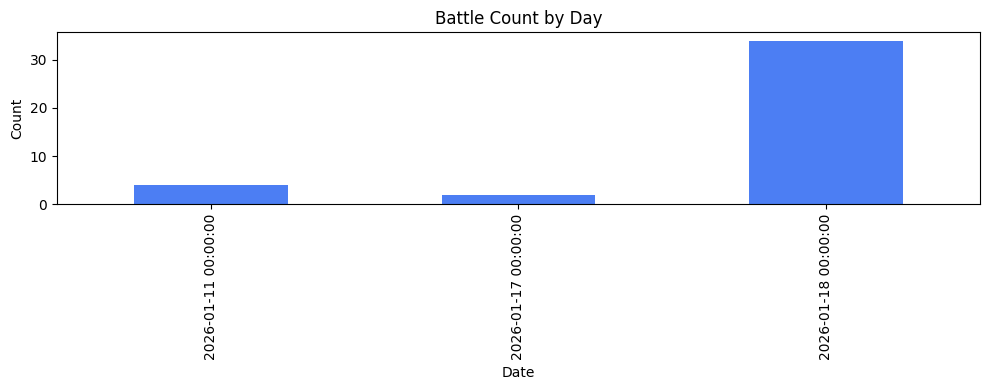

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import fusou_datasets

def load_table(name: str, master: bool = False):
    try:
        return fusou_datasets.load_master(name) if master else fusou_datasets.load(name, offline=True)
    except Exception:
        return fusou_datasets.load_master(name) if master else fusou_datasets.load(name, offline=False)

fusou_datasets.configure(cache_dir="~/.fusou_datasets/cache")

df_battle = load_table("battle")
if "timestamp" not in df_battle.columns:
    print("timestamp column not found in battle table")
else:
    ts = pd.to_datetime(df_battle["timestamp"], unit="s")
    daily = ts.dt.floor("D").value_counts().sort_index()
    plt.figure(figsize=(10, 4))
    daily.plot(kind="bar", color="#4C7EF3")
    plt.title("Battle Count by Day")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()